# 第 5 章 · 经典路线图搜索代码实验

本页把同一张路线图交给五种搜索策略。读者先确认城市、道路和启发式距离，再逐个运行算法，看 frontier 如何变化，最后比较它们找到的路线和代价。

[章节网页](../ch5.html)

## 运行内容

- 构建路线图和邻接表
- 实现 DFS、BFS、UCS、Greedy、A*
- 查看每个算法的展开过程、路径图和代价

## 0. 图数据与画图

先把问题转成图：节点是城市，边是道路距离，h 是到终点的直线距离估计。后面的所有算法都只读取这张图。

In [1]:
# 载入本页会用到的数据处理、队列和绘图工具。
import importlib.util
import logging
import subprocess
import sys
import warnings
from collections import deque
import heapq
from pathlib import Path

required_packages = {
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# AIMA Romania map：从 Arad 搜索到 Bucharest。
graph = {
    "start": "Arad",
    "goal": "Bucharest",
    "nodes": {
        "Arad": {"name": "Arad", "h": 366},
        "Zerind": {"name": "Zerind", "h": 374},
        "Oradea": {"name": "Oradea", "h": 380},
        "Sibiu": {"name": "Sibiu", "h": 253},
        "Timisoara": {"name": "Timisoara", "h": 329},
        "Lugoj": {"name": "Lugoj", "h": 244},
        "Mehadia": {"name": "Mehadia", "h": 241},
        "Dobreta": {"name": "Dobreta", "h": 242},
        "Craiova": {"name": "Craiova", "h": 160},
        "Rimnicu Vilcea": {"name": "Rimnicu Vilcea", "h": 193},
        "Fagaras": {"name": "Fagaras", "h": 176},
        "Pitesti": {"name": "Pitesti", "h": 100},
        "Bucharest": {"name": "Bucharest", "h": 0},
        "Giurgiu": {"name": "Giurgiu", "h": 77},
        "Urziceni": {"name": "Urziceni", "h": 80},
        "Hirsova": {"name": "Hirsova", "h": 151},
        "Eforie": {"name": "Eforie", "h": 161},
        "Vaslui": {"name": "Vaslui", "h": 199},
        "Iasi": {"name": "Iasi", "h": 226},
        "Neamt": {"name": "Neamt", "h": 234},
    },
    "edges": [
        {"from": "Arad", "to": "Zerind", "cost": 75},
        {"from": "Arad", "to": "Sibiu", "cost": 140},
        {"from": "Arad", "to": "Timisoara", "cost": 118},
        {"from": "Zerind", "to": "Oradea", "cost": 71},
        {"from": "Oradea", "to": "Sibiu", "cost": 151},
        {"from": "Timisoara", "to": "Lugoj", "cost": 111},
        {"from": "Lugoj", "to": "Mehadia", "cost": 70},
        {"from": "Mehadia", "to": "Dobreta", "cost": 75},
        {"from": "Dobreta", "to": "Craiova", "cost": 120},
        {"from": "Craiova", "to": "Rimnicu Vilcea", "cost": 146},
        {"from": "Craiova", "to": "Pitesti", "cost": 138},
        {"from": "Sibiu", "to": "Fagaras", "cost": 99},
        {"from": "Sibiu", "to": "Rimnicu Vilcea", "cost": 80},
        {"from": "Rimnicu Vilcea", "to": "Pitesti", "cost": 97},
        {"from": "Fagaras", "to": "Bucharest", "cost": 211},
        {"from": "Pitesti", "to": "Bucharest", "cost": 101},
        {"from": "Bucharest", "to": "Giurgiu", "cost": 90},
        {"from": "Bucharest", "to": "Urziceni", "cost": 85},
        {"from": "Urziceni", "to": "Hirsova", "cost": 98},
        {"from": "Hirsova", "to": "Eforie", "cost": 86},
        {"from": "Urziceni", "to": "Vaslui", "cost": 142},
        {"from": "Vaslui", "to": "Iasi", "cost": 92},
        {"from": "Iasi", "to": "Neamt", "cost": 87},
    ],
}

start = graph["start"]
goal = graph["goal"]
h = {node: meta["h"] for node, meta in graph["nodes"].items()}
print("start:", start, "goal:", goal)

start: Arad goal: Bucharest


In [3]:
# 把边表转成邻接表：搜索算法只需要知道“当前节点能走向哪些邻居”。
adj = {}
for edge in graph["edges"]:
    a = edge["from"]
    b = edge["to"]
    cost = edge["cost"]
    adj.setdefault(a, []).append((b, cost))
    adj.setdefault(b, []).append((a, cost))

for neighbors in adj.values():
    neighbors.sort(key=lambda item: item[0])

adj

{'Arad': [('Sibiu', 140), ('Timisoara', 118), ('Zerind', 75)],
 'Zerind': [('Arad', 75), ('Oradea', 71)],
 'Sibiu': [('Arad', 140),
  ('Fagaras', 99),
  ('Oradea', 151),
  ('Rimnicu Vilcea', 80)],
 'Timisoara': [('Arad', 118), ('Lugoj', 111)],
 'Oradea': [('Sibiu', 151), ('Zerind', 71)],
 'Lugoj': [('Mehadia', 70), ('Timisoara', 111)],
 'Mehadia': [('Dobreta', 75), ('Lugoj', 70)],
 'Dobreta': [('Craiova', 120), ('Mehadia', 75)],
 'Craiova': [('Dobreta', 120), ('Pitesti', 138), ('Rimnicu Vilcea', 146)],
 'Rimnicu Vilcea': [('Craiova', 146), ('Pitesti', 97), ('Sibiu', 80)],
 'Pitesti': [('Bucharest', 101), ('Craiova', 138), ('Rimnicu Vilcea', 97)],
 'Fagaras': [('Bucharest', 211), ('Sibiu', 99)],
 'Bucharest': [('Fagaras', 211),
  ('Giurgiu', 90),
  ('Pitesti', 101),
  ('Urziceni', 85)],
 'Giurgiu': [('Bucharest', 90)],
 'Urziceni': [('Bucharest', 85), ('Hirsova', 98), ('Vaslui', 142)],
 'Hirsova': [('Eforie', 86), ('Urziceni', 98)],
 'Eforie': [('Hirsova', 86)],
 'Vaslui': [('Iasi', 92)

In [4]:
# 节点表给出直线距离启发式 h，边表给出相邻城市距离。
nodes_df = pd.DataFrame(
    [
        {"节点": node, "名称": meta["name"], "h(到 Bucharest)": meta["h"]}
        for node, meta in graph["nodes"].items()
    ]
).sort_values("节点")

edges_df = pd.DataFrame(
    [
        {"边": f"{edge['from']}↔{edge['to']}", "代价": edge["cost"]}
        for edge in graph["edges"]
    ]
)

display(nodes_df)
display(edges_df)

,节点,名称,h(到 Bucharest)
0,Arad,Arad,366
12,Bucharest,Bucharest,0
8,Craiova,Craiova,160
7,Dobreta,Dobreta,242
16,Eforie,Eforie,161
10,Fagaras,Fagaras,176
13,Giurgiu,Giurgiu,77
15,Hirsova,Hirsova,151
18,Iasi,Iasi,226
5,Lugoj,Lugoj,244


,边,代价
0,Arad↔Zerind,75
1,Arad↔Sibiu,140
2,Arad↔Timisoara,118
3,Zerind↔Oradea,71
4,Oradea↔Sibiu,151
5,Timisoara↔Lugoj,111
6,Lugoj↔Mehadia,70
7,Mehadia↔Dobreta,75
8,Dobreta↔Craiova,120
9,Craiova↔Rimnicu Vilcea,146


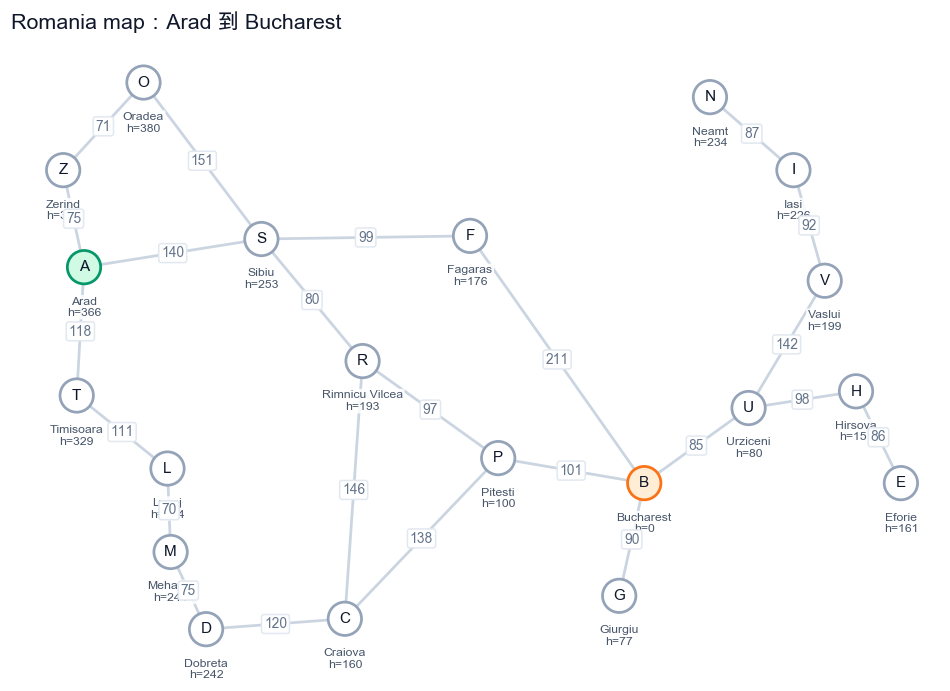

In [5]:
# 绘制 Romania map：高亮已展开节点和最终路线。
layout = {
    "Arad": (0.45, 3.25),
    "Zerind": (0.25, 4.18),
    "Oradea": (1.02, 5.02),
    "Sibiu": (2.15, 3.52),
    "Timisoara": (0.38, 2.02),
    "Lugoj": (1.25, 1.32),
    "Mehadia": (1.28, 0.52),
    "Dobreta": (1.62, -0.22),
    "Craiova": (2.95, -0.12),
    "Rimnicu Vilcea": (3.12, 2.35),
    "Fagaras": (4.15, 3.55),
    "Pitesti": (4.42, 1.42),
    "Bucharest": (5.82, 1.18),
    "Giurgiu": (5.58, 0.10),
    "Urziceni": (6.82, 1.90),
    "Hirsova": (7.85, 2.06),
    "Eforie": (8.28, 1.18),
    "Vaslui": (7.55, 3.12),
    "Iasi": (7.25, 4.18),
    "Neamt": (6.45, 4.88),
}


def edge_key(a, b):
    return tuple(sorted((a, b)))


def path_edges(path):
    return {edge_key(path[i], path[i + 1]) for i in range(len(path) - 1)}


def draw_search_result(path=None, trace=None, title="Romania map search"):
    path = path or []
    active_edges = path_edges(path)
    visited_nodes = set(path)
    if trace is not None and not trace.empty:
        visited_nodes.update(trace["取出节点"].tolist())

    fig, ax = plt.subplots(figsize=(11.4, 6.4))
    ax.set_facecolor("#fbfcfd")

    drawn_edges = set()
    for a, neighbors in adj.items():
        for b, cost in neighbors:
            key = edge_key(a, b)
            if key in drawn_edges:
                continue
            drawn_edges.add(key)
            x1, y1 = layout[a]
            x2, y2 = layout[b]
            is_path = key in active_edges
            ax.plot(
                [x1, x2],
                [y1, y2],
                color="#2563eb" if is_path else "#cbd5e1",
                linewidth=3.2 if is_path else 1.8,
                solid_capstyle="round",
                zorder=2 if is_path else 1,
            )
            ax.text(
                (x1 + x2) / 2,
                (y1 + y2) / 2,
                str(cost),
                ha="center",
                va="center",
                fontsize=9,
                color="#1d4ed8" if is_path else "#64748b",
                bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "#e2e8f0"},
                zorder=4,
            )

    for node, (x, y) in layout.items():
        is_start = node == start
        is_goal = node == goal
        is_visited = node in visited_nodes
        face = "#eff6ff" if is_visited else "#ffffff"
        edge = "#2563eb" if is_visited else "#94a3b8"
        if is_start:
            face, edge = "#d1fae5", "#059669"
        if is_goal:
            face, edge = "#ffedd5", "#f97316"
        circle = plt.Circle((x, y), 0.16, facecolor=face, edgecolor=edge, linewidth=1.8, zorder=5)
        ax.add_patch(circle)
        ax.text(x, y, node[:1], ha="center", va="center", fontweight="bold", color="#0f172a", zorder=6)
        ax.text(
            x,
            y - 0.28,
            f"{graph['nodes'][node]['name']}\nh={h[node]}",
            ha="center",
            va="top",
            fontsize=8,
            color="#475569",
            bbox={"boxstyle": "round,pad=0.12", "fc": "white", "ec": "none", "alpha": 0.85},
        )

    if path:
        total = path_cost(path)
        ax.text(
            0.04,
            0.05,
            f"path: {' -> '.join(path)}   cost={total}",
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=10,
            color="#334155",
            bbox={"boxstyle": "round,pad=0.32", "fc": "white", "ec": "#e2e8f0"},
        )

    ax.set_title(title, loc="left", fontsize=14, fontweight="bold", color="#0f172a")
    ax.set_xlim(-0.25, 8.65)
    ax.set_ylim(-0.62, 5.45)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_search_result(title="Romania map：Arad 到 Bucharest")

## 1. 搜索算法

这一组 cell 保留完整算法代码。重点看每种算法的 frontier 数据结构：DFS 用栈，BFS 用队列，UCS/Greedy/A* 用优先队列，但排序依据不同。

In [6]:
# 路径辅助函数：回溯路线、计算总代价、格式化候选队列。
def reconstruct_path(parent, goal):
    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = parent.get(current)
    return list(reversed(path))


def path_cost(path):
    total = 0
    for a, b in zip(path, path[1:]):
        for nbr, cost in adj[a]:
            if nbr == b:
                total += cost
                break
    return total


def frontier_text(items):
    return " | ".join(items) if items else "∅"

In [7]:
# DFS：使用栈；最后加入的候选节点最先展开。
def dfs(start, goal, adj):
    stack = [(start, [start], 0)]
    visited = set()
    rows = []
    step = 0

    while stack:
        step += 1
        before = [item[0] for item in stack]
        node, path, cost = stack.pop()

        if node in visited:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "已访问，跳过",
                "当前路径": "→".join(path),
                "已访问": "→".join(sorted(visited)),
            })
            continue

        visited.add(node)
        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "已访问": "→".join(sorted(visited)),
            })
            return path, pd.DataFrame(rows)

        pushed = []
        for nbr, edge_cost in reversed(adj[node]):
            if nbr not in visited:
                stack.append((nbr, path + [nbr], cost + edge_cost))
                pushed.append(f"{nbr}(cost={cost + edge_cost})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(pushed),
            "当前路径": "→".join(path),
            "已访问": "→".join(sorted(visited)),
        })

    return [], pd.DataFrame(rows)

In [8]:
# BFS：使用队列；按边数层级一圈一圈向外扩展。
def bfs(start, goal, adj):
    queue = deque([(start, [start], 0)])
    discovered = {start}
    rows = []
    step = 0

    while queue:
        step += 1
        before = [item[0] for item in queue]
        node, path, cost = queue.popleft()

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "已发现": "→".join(sorted(discovered)),
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            if nbr not in discovered:
                discovered.add(nbr)
                queue.append((nbr, path + [nbr], cost + edge_cost))
                added.append(nbr)

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "已发现": "→".join(sorted(discovered)),
        })

    return [], pd.DataFrame(rows)

In [9]:
# UCS：按累计代价 g 排序；优先展开当前最便宜的路线。
def ucs(start, goal, adj):
    frontier = [(0, start, [start])]
    best_cost = {start: 0}
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[1]}(g={item[0]})" for item in sorted(frontier)]
        cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "g": cost,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            new_cost = cost + edge_cost
            if nbr in visited or new_cost >= best_cost.get(nbr, float("inf")):
                continue
            best_cost[nbr] = new_cost
            heapq.heappush(frontier, (new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(g={new_cost})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "g": cost,
        })

    return [], pd.DataFrame(rows)

In [10]:
# Greedy：只看启发式 h；优先展开看起来更接近目标的节点。
def greedy(start, goal, adj, h):
    frontier = [(h[start], 0, start, [start])]
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[2]}(h={item[0]})" for item in sorted(frontier)]
        h_value, cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "h": h_value,
                "实际代价": cost,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            if nbr in visited:
                continue
            new_cost = cost + edge_cost
            heapq.heappush(frontier, (h[nbr], new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(h={h[nbr]})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "h": h_value,
            "实际代价": cost,
        })

    return [], pd.DataFrame(rows)

In [11]:
# A*：按 f=g+h 排序；同时考虑已走代价和剩余距离估计。
def astar(start, goal, adj, h):
    frontier = [(h[start], h[start], 0, start, [start])]
    best_cost = {start: 0}
    visited = set()
    rows = []
    step = 0

    while frontier:
        step += 1
        before = [f"{item[3]}(f={item[0]}, g={item[2]}, h={item[1]})" for item in sorted(frontier)]
        f_value, h_value, cost, node, path = heapq.heappop(frontier)

        if node in visited:
            continue
        visited.add(node)

        if node == goal:
            rows.append({
                "步骤": step,
                "frontier取出前": frontier_text(before),
                "取出节点": node,
                "新增候选": "到达目标",
                "当前路径": "→".join(path),
                "g": cost,
                "h": h_value,
                "f": f_value,
            })
            return path, pd.DataFrame(rows)

        added = []
        for nbr, edge_cost in adj[node]:
            new_cost = cost + edge_cost
            if nbr in visited or new_cost >= best_cost.get(nbr, float("inf")):
                continue
            best_cost[nbr] = new_cost
            new_h = h[nbr]
            new_f = new_cost + new_h
            heapq.heappush(frontier, (new_f, new_h, new_cost, nbr, path + [nbr]))
            added.append(f"{nbr}(f={new_f}, g={new_cost}, h={new_h})")

        rows.append({
            "步骤": step,
            "frontier取出前": frontier_text(before),
            "取出节点": node,
            "新增候选": frontier_text(added),
            "当前路径": "→".join(path),
            "g": cost,
            "h": h_value,
            "f": f_value,
        })

    return [], pd.DataFrame(rows)

## 2. 逐个运行并查看过程

每个算法都会输出展开表和路径图。展开表用于看“下一步为什么选它”，路径图用于看“最终路线是否真的更短”。

### 2.1 DFS

,步骤,frontier取出前,取出节点,新增候选,当前路径,已访问
0,1,Arad,Arad,Zerind(cost=75) | Timisoara(cost=118) | Sibiu(...,Arad,Arad
1,2,Zerind | Timisoara | Sibiu,Sibiu,Rimnicu Vilcea(cost=220) | Oradea(cost=291) | ...,Arad→Sibiu,Arad→Sibiu
2,3,Zerind | Timisoara | Rimnicu Vilcea | Oradea |...,Fagaras,Bucharest(cost=450),Arad→Sibiu→Fagaras,Arad→Fagaras→Sibiu
3,4,Zerind | Timisoara | Rimnicu Vilcea | Oradea |...,Bucharest,到达目标,Arad→Sibiu→Fagaras→Bucharest,Arad→Bucharest→Fagaras→Sibiu


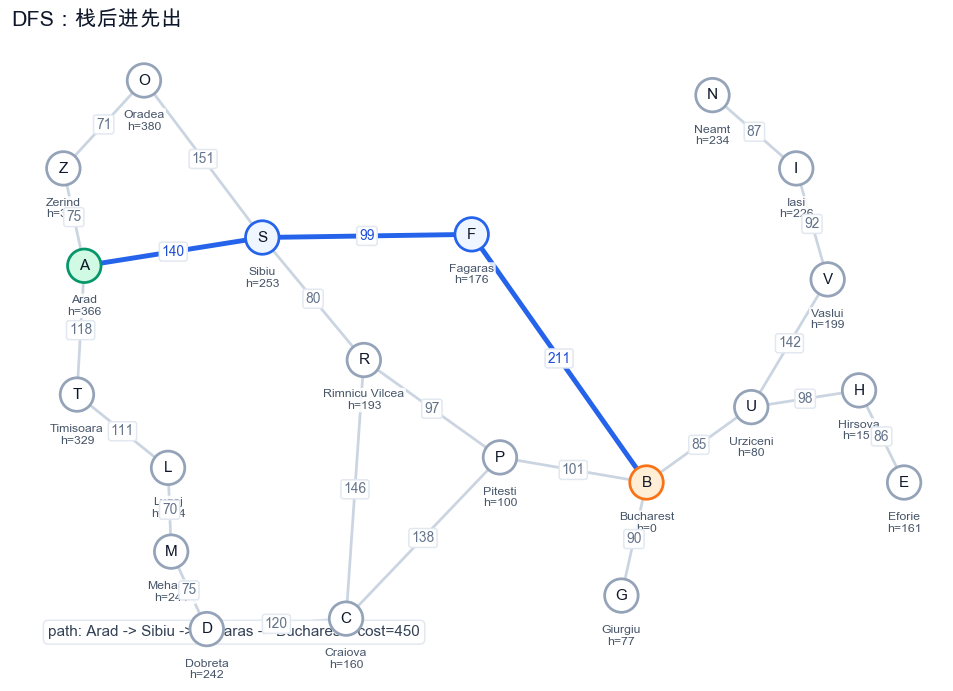

In [12]:
# 运行 DFS：查看栈的展开过程和最终路线。
dfs_path, dfs_trace = dfs(start, goal, adj)
display(dfs_trace)
draw_search_result(dfs_path, dfs_trace, "DFS：栈后进先出")

### 2.2 BFS

,步骤,frontier取出前,取出节点,新增候选,当前路径,已发现
0,1,Arad,Arad,Sibiu | Timisoara | Zerind,Arad,Arad→Sibiu→Timisoara→Zerind
1,2,Sibiu | Timisoara | Zerind,Sibiu,Fagaras | Oradea | Rimnicu Vilcea,Arad→Sibiu,Arad→Fagaras→Oradea→Rimnicu Vilcea→Sibiu→Timis...
2,3,Timisoara | Zerind | Fagaras | Oradea | Rimnic...,Timisoara,Lugoj,Arad→Timisoara,Arad→Fagaras→Lugoj→Oradea→Rimnicu Vilcea→Sibiu...
3,4,Zerind | Fagaras | Oradea | Rimnicu Vilcea | L...,Zerind,∅,Arad→Zerind,Arad→Fagaras→Lugoj→Oradea→Rimnicu Vilcea→Sibiu...
4,5,Fagaras | Oradea | Rimnicu Vilcea | Lugoj,Fagaras,Bucharest,Arad→Sibiu→Fagaras,Arad→Bucharest→Fagaras→Lugoj→Oradea→Rimnicu Vi...
5,6,Oradea | Rimnicu Vilcea | Lugoj | Bucharest,Oradea,∅,Arad→Sibiu→Oradea,Arad→Bucharest→Fagaras→Lugoj→Oradea→Rimnicu Vi...
6,7,Rimnicu Vilcea | Lugoj | Bucharest,Rimnicu Vilcea,Craiova | Pitesti,Arad→Sibiu→Rimnicu Vilcea,Arad→Bucharest→Craiova→Fagaras→Lugoj→Oradea→Pi...
7,8,Lugoj | Bucharest | Craiova | Pitesti,Lugoj,Mehadia,Arad→Timisoara→Lugoj,Arad→Bucharest→Craiova→Fagaras→Lugoj→Mehadia→O...
8,9,Bucharest | Craiova | Pitesti | Mehadia,Bucharest,到达目标,Arad→Sibiu→Fagaras→Bucharest,Arad→Bucharest→Craiova→Fagaras→Lugoj→Mehadia→O...


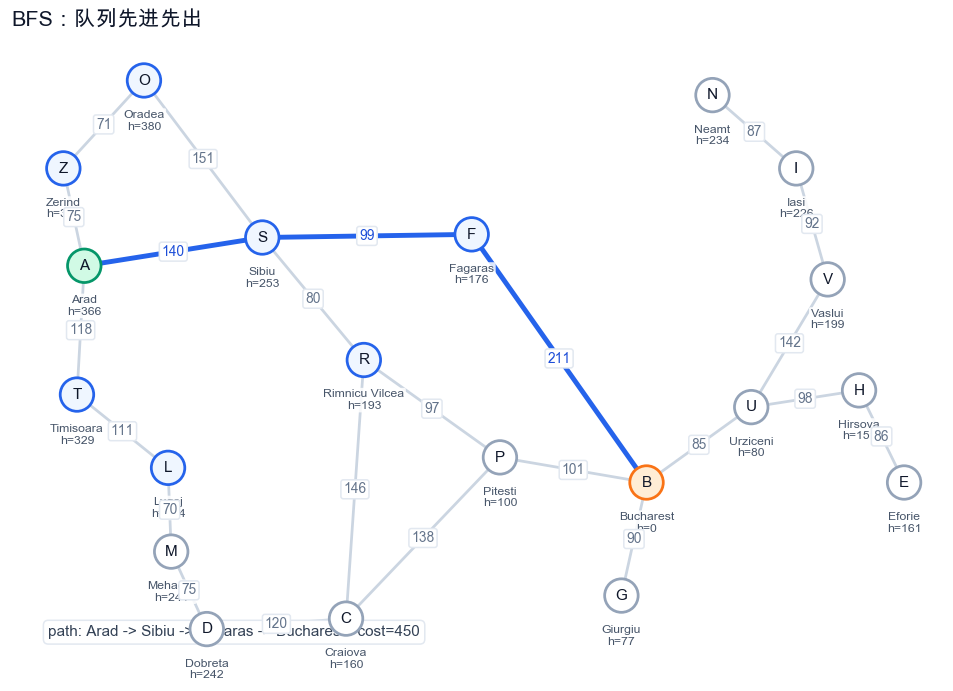

In [13]:
# 运行 BFS：查看队列的展开过程和最终路线。
bfs_path, bfs_trace = bfs(start, goal, adj)
display(bfs_trace)
draw_search_result(bfs_path, bfs_trace, "BFS：队列先进先出")

### 2.3 UCS

,步骤,frontier取出前,取出节点,新增候选,当前路径,g
0,1,Arad(g=0),Arad,Sibiu(g=140) | Timisoara(g=118) | Zerind(g=75),Arad,0
1,2,Zerind(g=75) | Timisoara(g=118) | Sibiu(g=140),Zerind,Oradea(g=146),Arad→Zerind,75
2,3,Timisoara(g=118) | Sibiu(g=140) | Oradea(g=146),Timisoara,Lugoj(g=229),Arad→Timisoara,118
3,4,Sibiu(g=140) | Oradea(g=146) | Lugoj(g=229),Sibiu,Fagaras(g=239) | Rimnicu Vilcea(g=220),Arad→Sibiu,140
4,5,Oradea(g=146) | Rimnicu Vilcea(g=220) | Lugoj(...,Oradea,∅,Arad→Zerind→Oradea,146
5,6,Rimnicu Vilcea(g=220) | Lugoj(g=229) | Fagaras...,Rimnicu Vilcea,Craiova(g=366) | Pitesti(g=317),Arad→Sibiu→Rimnicu Vilcea,220
6,7,Lugoj(g=229) | Fagaras(g=239) | Pitesti(g=317)...,Lugoj,Mehadia(g=299),Arad→Timisoara→Lugoj,229
7,8,Fagaras(g=239) | Mehadia(g=299) | Pitesti(g=31...,Fagaras,Bucharest(g=450),Arad→Sibiu→Fagaras,239
8,9,Mehadia(g=299) | Pitesti(g=317) | Craiova(g=36...,Mehadia,Dobreta(g=374),Arad→Timisoara→Lugoj→Mehadia,299
9,10,Pitesti(g=317) | Craiova(g=366) | Dobreta(g=37...,Pitesti,Bucharest(g=418),Arad→Sibiu→Rimnicu Vilcea→Pitesti,317


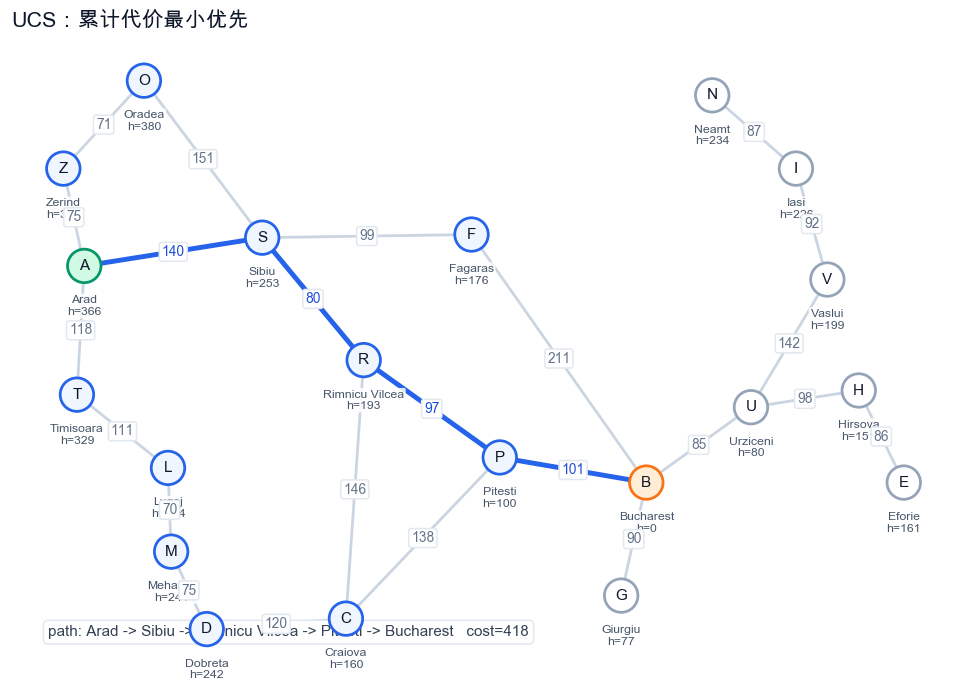

In [14]:
# 运行 UCS：查看按累计代价 g 选择节点的过程。
ucs_path, ucs_trace = ucs(start, goal, adj)
display(ucs_trace)
draw_search_result(ucs_path, ucs_trace, "UCS：累计代价最小优先")

### 2.4 Greedy

,步骤,frontier取出前,取出节点,新增候选,当前路径,h,实际代价
0,1,Arad(h=366),Arad,Sibiu(h=253) | Timisoara(h=329) | Zerind(h=374),Arad,366,0
1,2,Sibiu(h=253) | Timisoara(h=329) | Zerind(h=374),Sibiu,Fagaras(h=176) | Oradea(h=380) | Rimnicu Vilce...,Arad→Sibiu,253,140
2,3,Fagaras(h=176) | Rimnicu Vilcea(h=193) | Timis...,Fagaras,Bucharest(h=0),Arad→Sibiu→Fagaras,176,239
3,4,Bucharest(h=0) | Rimnicu Vilcea(h=193) | Timis...,Bucharest,到达目标,Arad→Sibiu→Fagaras→Bucharest,0,450


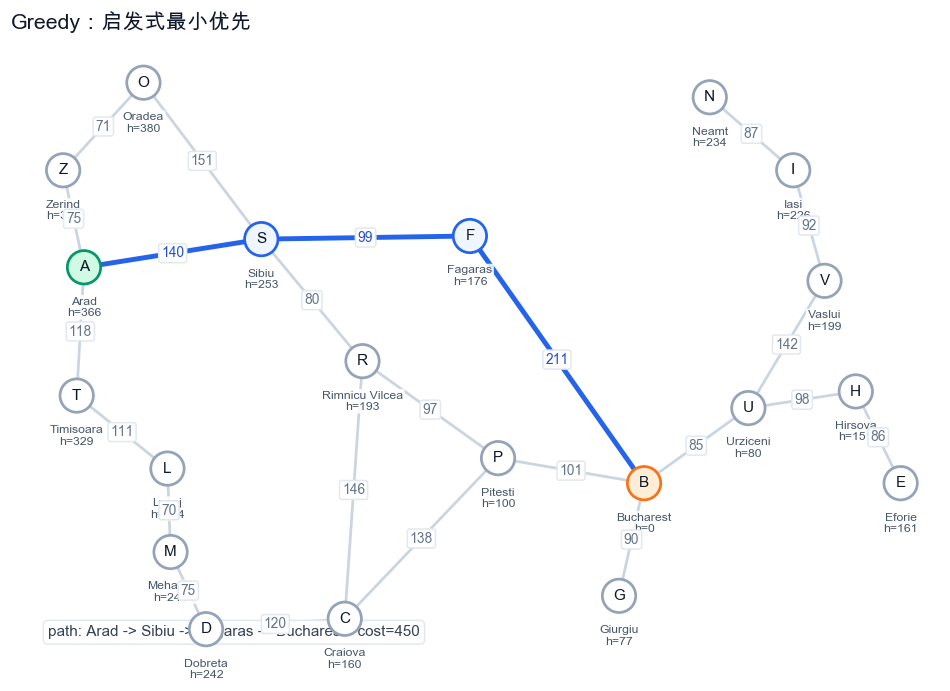

In [15]:
# 运行 Greedy：查看按启发式 h 选择节点的过程。
greedy_path, greedy_trace = greedy(start, goal, adj, h)
display(greedy_trace)
draw_search_result(greedy_path, greedy_trace, "Greedy：启发式最小优先")

### 2.5 A*

,步骤,frontier取出前,取出节点,新增候选,当前路径,g,h,f
0,1,"Arad(f=366, g=0, h=366)",Arad,"Sibiu(f=393, g=140, h=253) | Timisoara(f=447, ...",Arad,0,366,366
1,2,"Sibiu(f=393, g=140, h=253) | Timisoara(f=447, ...",Sibiu,"Fagaras(f=415, g=239, h=176) | Oradea(f=671, g...",Arad→Sibiu,140,253,393
2,3,"Rimnicu Vilcea(f=413, g=220, h=193) | Fagaras(...",Rimnicu Vilcea,"Craiova(f=526, g=366, h=160) | Pitesti(f=417, ...",Arad→Sibiu→Rimnicu Vilcea,220,193,413
3,4,"Fagaras(f=415, g=239, h=176) | Pitesti(f=417, ...",Fagaras,"Bucharest(f=450, g=450, h=0)",Arad→Sibiu→Fagaras,239,176,415
4,5,"Pitesti(f=417, g=317, h=100) | Timisoara(f=447...",Pitesti,"Bucharest(f=418, g=418, h=0)",Arad→Sibiu→Rimnicu Vilcea→Pitesti,317,100,417
5,6,"Bucharest(f=418, g=418, h=0) | Timisoara(f=447...",Bucharest,到达目标,Arad→Sibiu→Rimnicu Vilcea→Pitesti→Bucharest,418,0,418


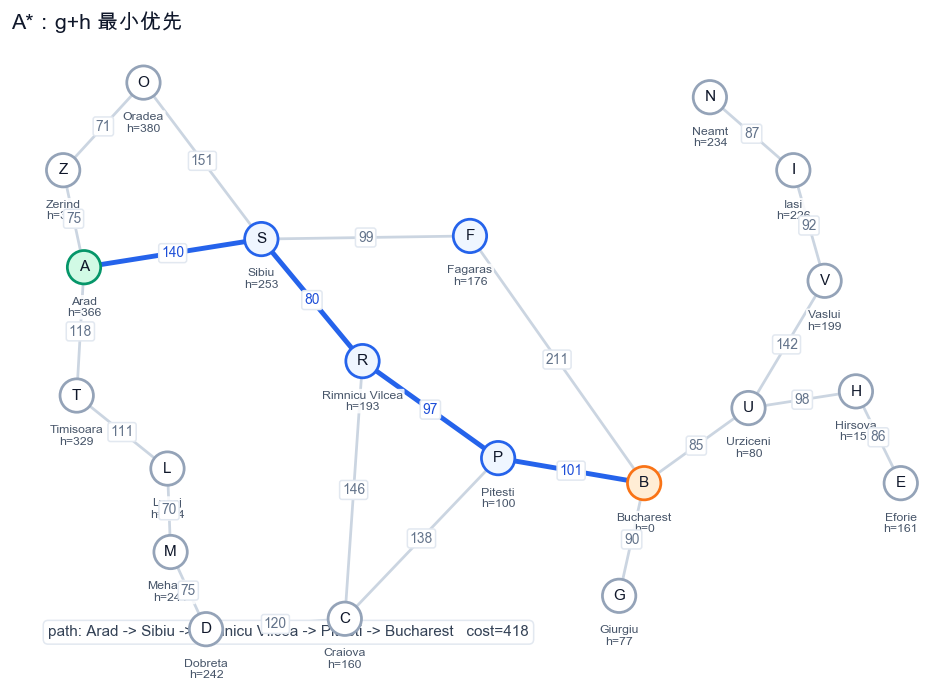

In [16]:
# 运行 A*：查看按 f=g+h 选择节点的过程。
astar_path, astar_trace = astar(start, goal, adj, h)
display(astar_trace)
draw_search_result(astar_path, astar_trace, "A*：g+h 最小优先")

## 3. 结果汇总

最后把路线、边数和总代价放在一起。读者可以直接比较：少走几条边不一定总代价最低，只看启发式也可能走偏。

In [17]:
# 汇总五种搜索策略的路线、边数和总代价。
summary_df = pd.DataFrame(
    [
        {"算法": "DFS", "路径": "→".join(dfs_path), "边数": len(dfs_path) - 1, "代价": path_cost(dfs_path)},
        {"算法": "BFS", "路径": "→".join(bfs_path), "边数": len(bfs_path) - 1, "代价": path_cost(bfs_path)},
        {"算法": "UCS", "路径": "→".join(ucs_path), "边数": len(ucs_path) - 1, "代价": path_cost(ucs_path)},
        {"算法": "Greedy", "路径": "→".join(greedy_path), "边数": len(greedy_path) - 1, "代价": path_cost(greedy_path)},
        {"算法": "A*", "路径": "→".join(astar_path), "边数": len(astar_path) - 1, "代价": path_cost(astar_path)},
    ]
)
display(summary_df)

,算法,路径,边数,代价
0,DFS,Arad→Sibiu→Fagaras→Bucharest,3,450
1,BFS,Arad→Sibiu→Fagaras→Bucharest,3,450
2,UCS,Arad→Sibiu→Rimnicu Vilcea→Pitesti→Bucharest,4,418
3,Greedy,Arad→Sibiu→Fagaras→Bucharest,3,450
4,A*,Arad→Sibiu→Rimnicu Vilcea→Pitesti→Bucharest,4,418
